# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# 1. Business Understanding
Goal: ?

# 2. Data Understanding

## 2.1 Load dataset

In [9]:
## Read *.csv file into pandas DataFrame
df = pd.read_csv('online_shoppers_intention.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2.2 Summary Statistics

In [10]:
## Understand the type of variable for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [11]:
## Check for missing data
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [12]:
## Describe data distribution
df.describe(include="all")

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

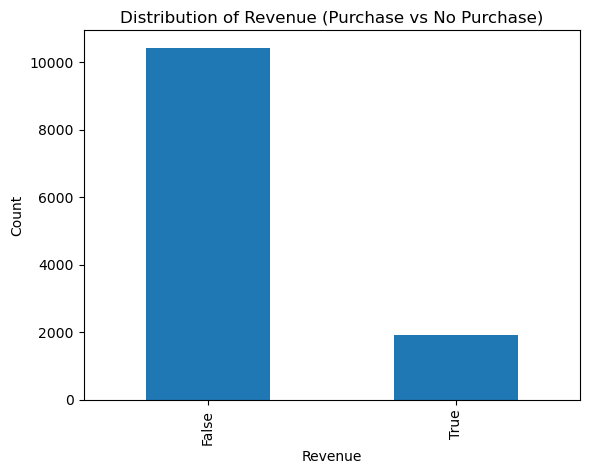

In [13]:
## Understanding distribution of target
df['Revenue'].value_counts().plot(kind='bar')
plt.title("Distribution of Revenue (Purchase vs No Purchase)")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

### 2.3.1.2 Understanding distribution of features

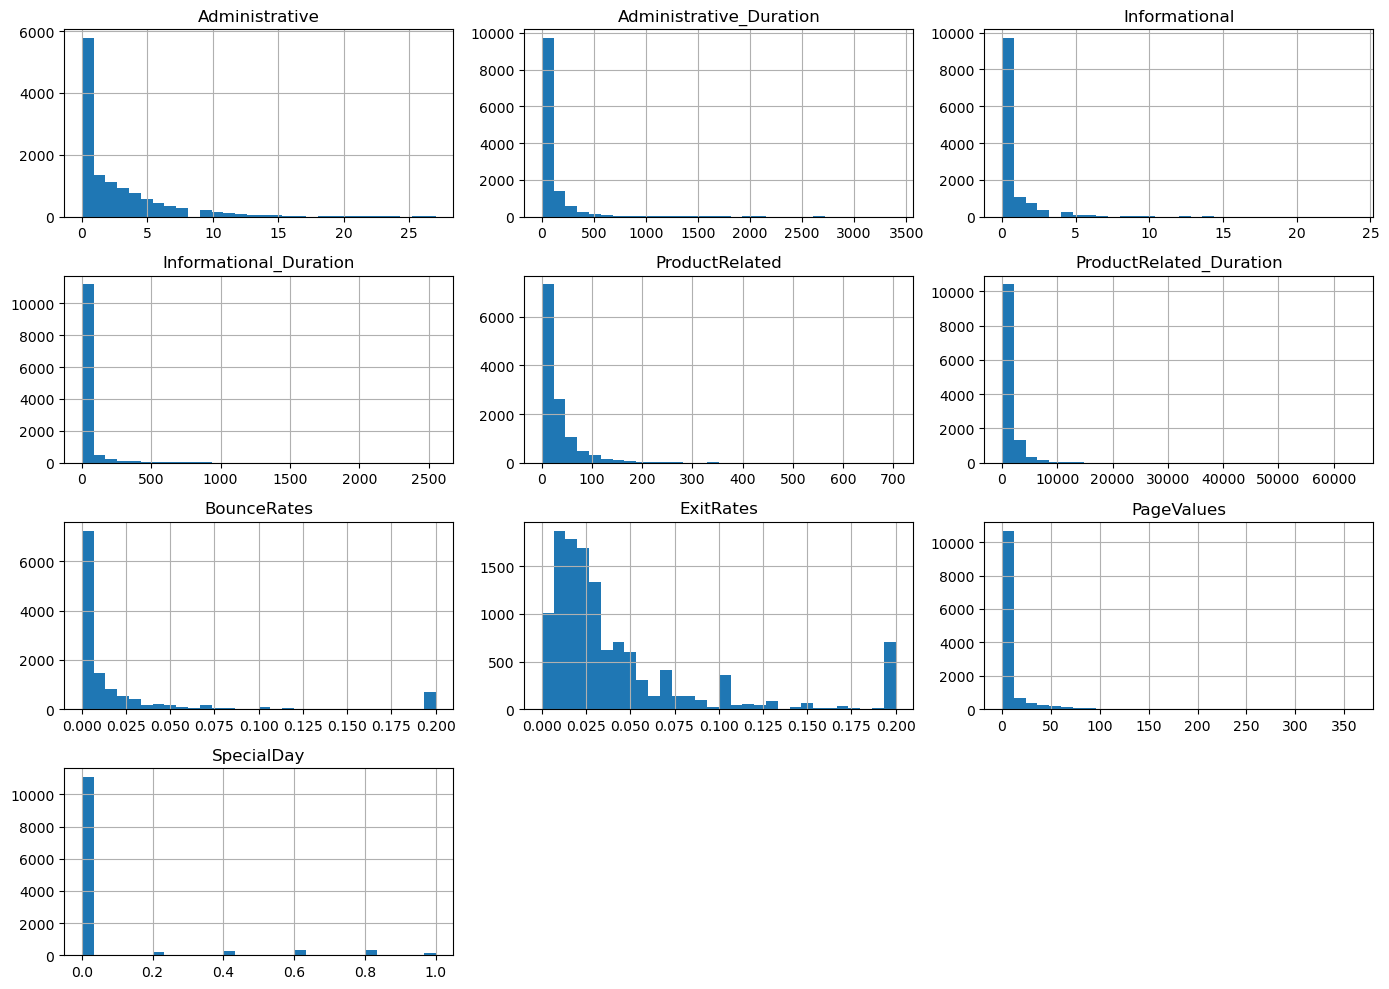

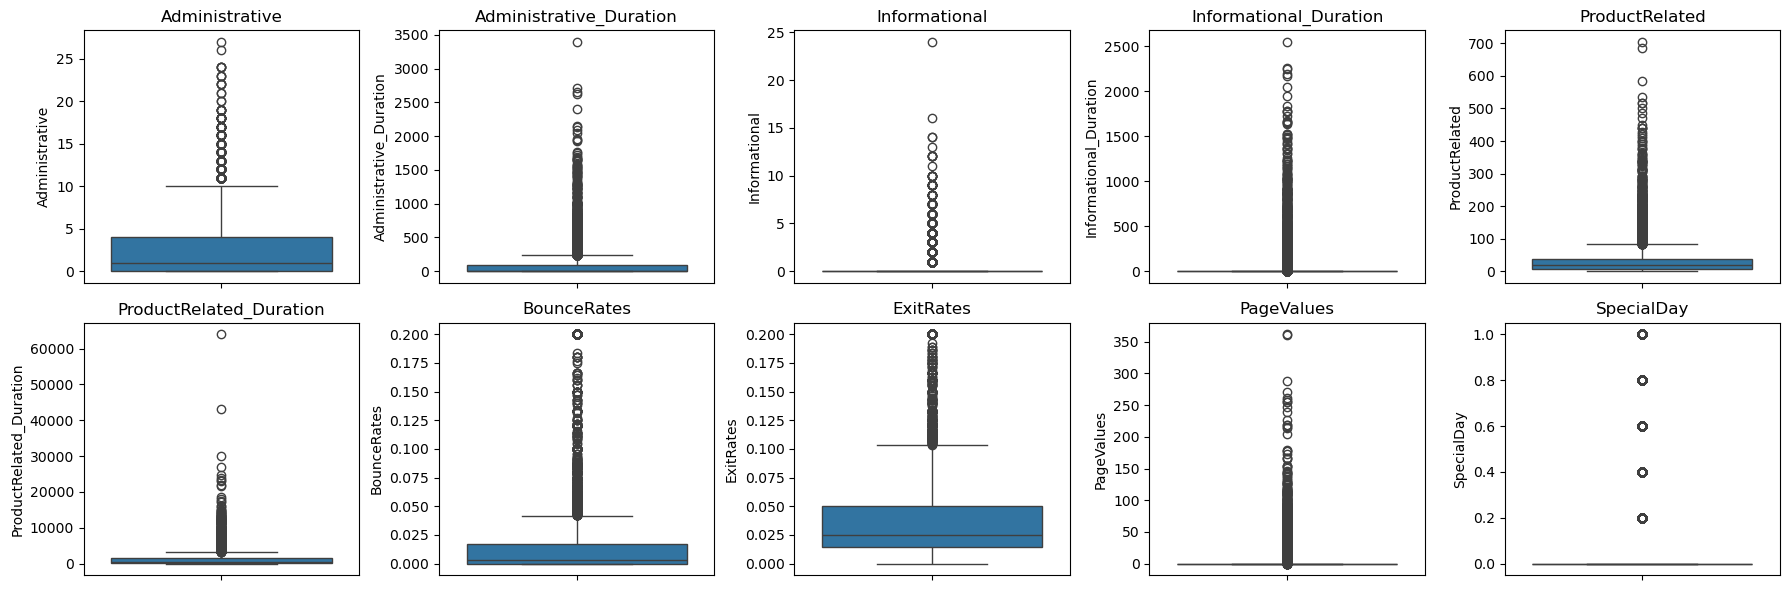

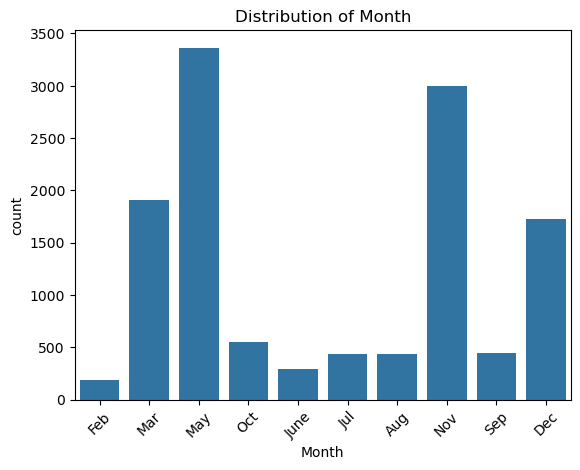

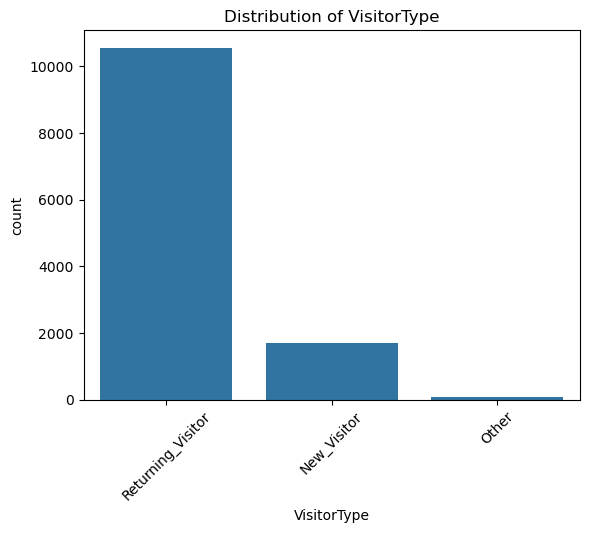

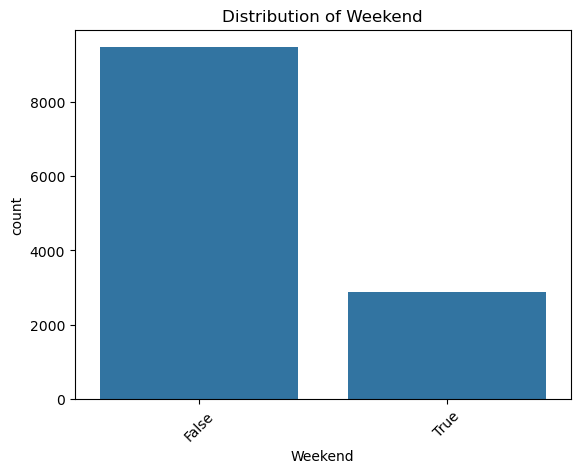

In [14]:
## Understanding distribution of features
num_cols = ['Administrative', 'Administrative_Duration', 'Informational',
            'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
for col in ['Month', 'VisitorType', 'Weekend']:
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

### 2.3.2 Understanding relationship between variables

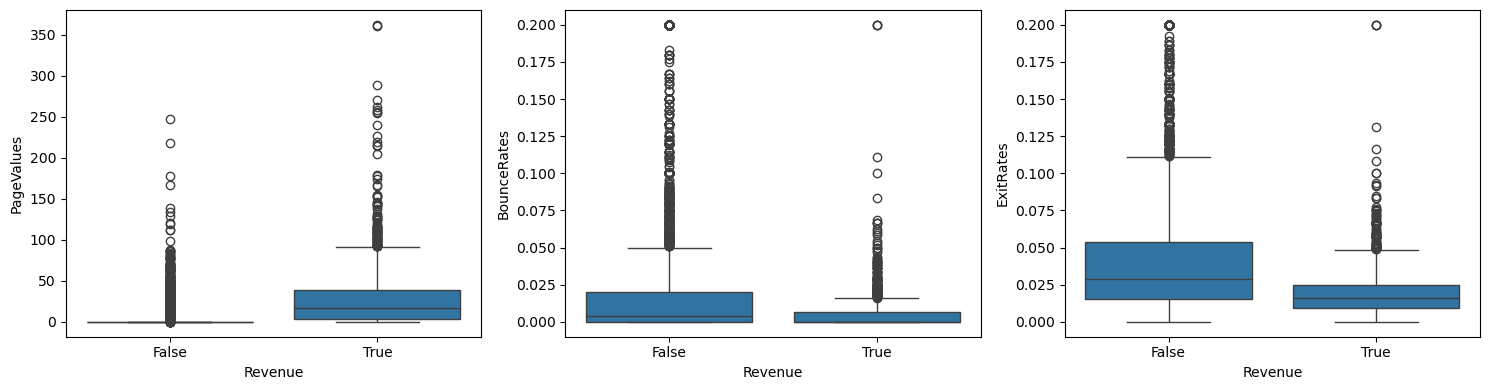

In [15]:
## Understanding relationship between variables
# Numeric features vs target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x='Revenue', y='PageValues', data=df, ax=axes[0])
sns.boxplot(x='Revenue', y='BounceRates', data=df, ax=axes[1])
sns.boxplot(x='Revenue', y='ExitRates', data=df, ax=axes[2])
plt.tight_layout()
plt.show()


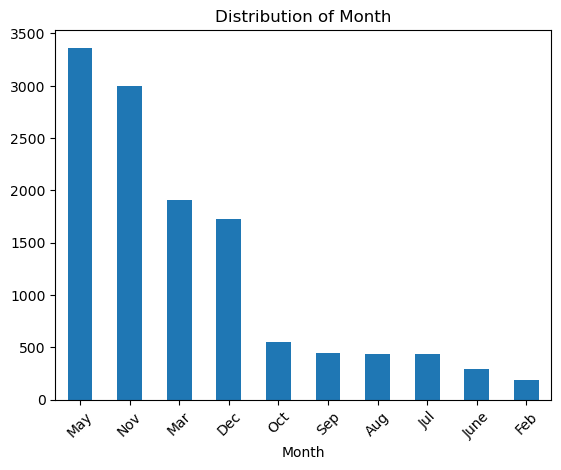

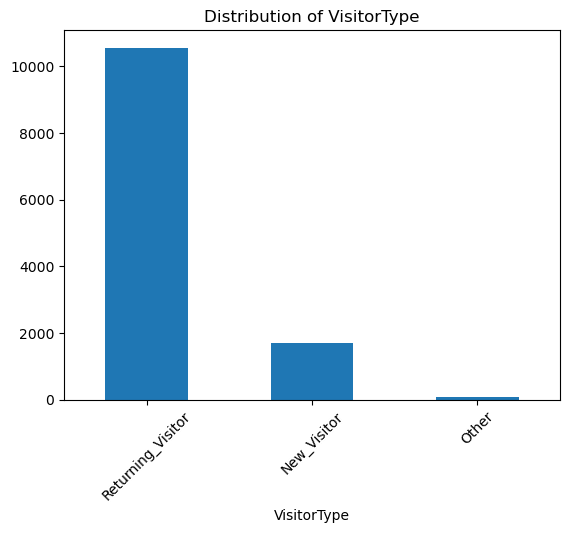

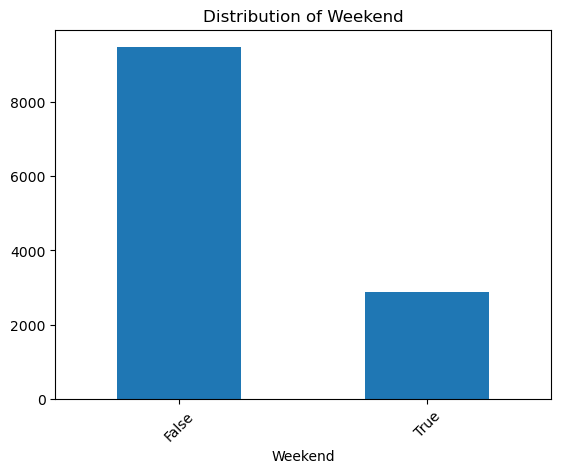

In [16]:
# Categorical vs target (revenue rate)
for col in ['Month', 'VisitorType', 'Weekend']:
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

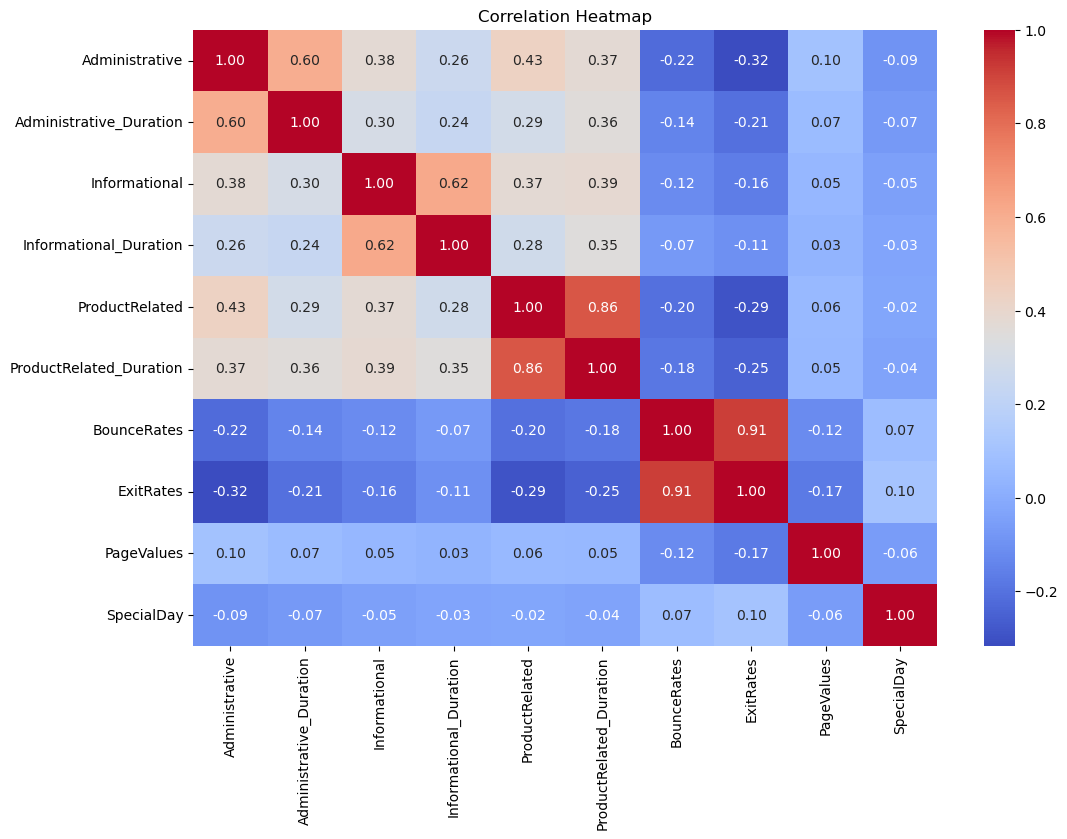

In [17]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

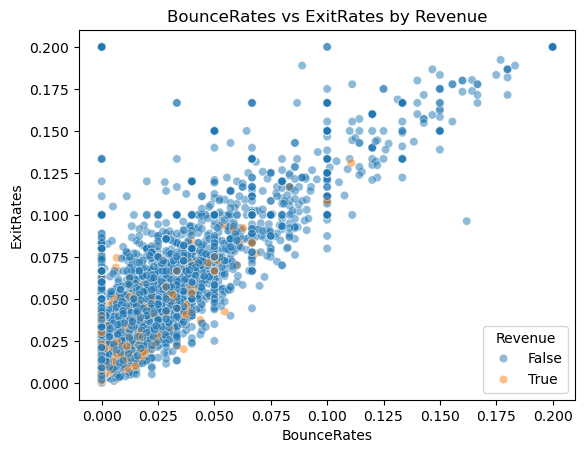

In [18]:
sns.scatterplot(x='BounceRates', y='ExitRates', hue='Revenue', data=df, alpha=0.5)
plt.title("BounceRates vs ExitRates by Revenue")
plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [19]:
# Clean data

# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicate rows 
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

# Convert boolean columns to int (0/1) so models can use them
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# One-Hot Encoding for categorical columns (Month, VisitorType)
# We use OHE instead of integer mapping since Month and VisitorType have no natural order
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)
df.head()
# preventing curse of dimensionality rows vs features ratio ( at least 10x more rows than features)
print("Rows:", df.shape[0], "| Features:", df.shape[1] - 1)

Duplicate rows: 125
Shape after removing duplicates: (12205, 18)
Rows: 12205 | Features: 26


## 3.2 Train-Test Split

In [20]:
# Split data into train set and test set

# Indicate X (features) and y (target)
X = df.drop(['Revenue'], axis=1)
y = df['Revenue']

# Split into train and test sets
test_size = 0.2
random_state = 2026

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=random_state
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9764, 26)
Test shape: (2441, 26)


In [21]:
print("Train purchase rate:", round(y_train.mean(), 3))
print("Test purchase rate:", round(y_test.mean(), 3))

Train purchase rate: 0.156
Test purchase rate: 0.156


# 4. Modelling

### 4.2 Train Model

In [27]:
# Initialise and train model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Logistic Regression
logr = LogisticRegression( random_state=2026, max_iter=1000)
logr.fit(X_train_scaled, y_train)

# Model 2: Random Forest
rf = RandomForestClassifier( random_state=2026)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

We train two distinct algorithms: Logistic Regression (linear, interpretable, requires feature scaling) and Random Forest (tree-based, captures non-linear patterns, scaling not required).

# 5. Model Evaluation

Random Forest outperforms Logistic Regressions recall (0.54 vs 0.35), F1-score (0.63 vs 0.48), 
and ROC-AUC (0.921 vs 0.885) for the purchase class we can see that the precision is roughly equal.

ROC-AUC (Receiver Operating Characteristic-Area Under Curve) shows how well a model can 
tell between the two classes purchase vs no purchase across all the possible decisions not the default 50% cutoff. A score of 1.0 means perfect separation between classes while 0.5 means the model performs no better than random guessing. Random Forests score of 0.921 vs 0.885 for Logistic Regression shows it is better at telling apart purchasers from non-purchasers overall.

Since the business goal is to flag as many likely purchasers as possible this metric is one of the most important ones that needs to be looked after so that we can accurate make a decsion whetever they are going to but or not.

In [28]:
## Evaluate model
y_pred_log = logr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)
#
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, logr.predict_proba(X_test_scaled)[:, 1]))

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2060
           1       0.75      0.35      0.48       381

    accuracy                           0.88      2441
   macro avg       0.82      0.66      0.71      2441
weighted avg       0.87      0.88      0.86      2441

ROC-AUC: 0.8848164003771374
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2060
           1       0.74      0.54      0.63       381

    accuracy                           0.90      2441
   macro avg       0.83      0.75      0.78      2441
weighted avg       0.89      0.90      0.89      2441

ROC-AUC: 0.9209540555003441


In [ ]:
## New data
# created unseen data that will be used 
new_session = pd.DataFrame([{
    'Administrative': 2, 'Administrative_Duration': 80.0,
    'Informational': 0, 'Informational_Duration': 0.0,
    'ProductRelated': 25, 'ProductRelated_Duration': 600.0,
    'BounceRates': 0.01, 'ExitRates': 0.02, 'PageValues': 15.0,
    'SpecialDay': 0.0, 'OperatingSystems': 2, 'Browser': 2,
    'Region': 1, 'TrafficType': 2, 'Weekend': 1,
    'Month': 'Nov', 'VisitorType': 'Returning_Visitor'
}])

# Applied the same one-hot encoding used on the training data
new_session_encoded = pd.get_dummies(new_session, columns=['Month', 'VisitorType'])

# Align columns with X_train adds any missing dummy columns as 0 and drops extras and the  matches order
new_session_encoded = new_session_encoded.reindex(columns=X_train.columns, fill_value=0)
new_session_encoded
## Predict using Random Forest 
##Random forest is used as it is the better model for this dataset and it does not require scaling of features
rf_prediction = rf.predict(new_session_encoded)
rf_probability = rf.predict_proba(new_session_encoded)[:, 1]

print("Random Forest prediction:", "Purchase" if rf_prediction[0] == 1 else "No Purchase")
print("Random Forest purchase probability:", round(rf_probability[0], 3))

# Predict using Logistic Regression needs to be  scaled first
new_session_scaled = scaler.transform(new_session_encoded)
logr_prediction = logr.predict(new_session_scaled)
logr_probability = logr.predict_proba(new_session_scaled)[:, 1]
print("Logistic Regression prediction:", "Purchase" if logr_prediction[0] == 1 else "No Purchase")
print("Logistic Regression purchase probability:", round(logr_probability[0], 3))

Random Forest prediction: Purchase
Random Forest purchase probability: 0.51
Logistic Regression prediction: No Purchase
Logistic Regression purchase probability: 0.41


## Iterative model development


In [25]:
## Further feature engineering / feature selection